In [1]:
# extract 8 bitplanes of an image (256x256 img)
# combine the bitplanes to get the image

In [2]:
# pip install opencv-python

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
img = cv2.imread("Z:/20XW97-CV-LAB/assets/images/casablanca.tif", 0)

In [27]:
m, n = img.shape

(-0.5, 459.5, 359.5, -0.5)

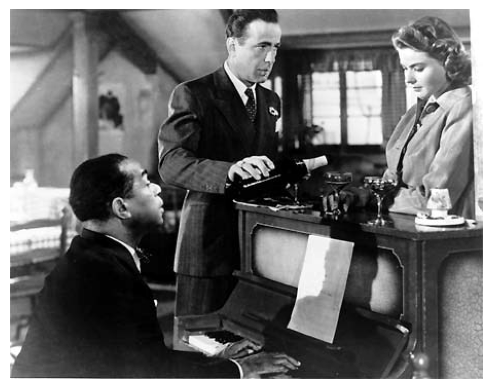

In [28]:
plt.imshow(img, cmap='gray')
plt.axis('off')

In [29]:
bitplanes = []

for i in range(8):
    bitplanes.append(img & (1<<i))

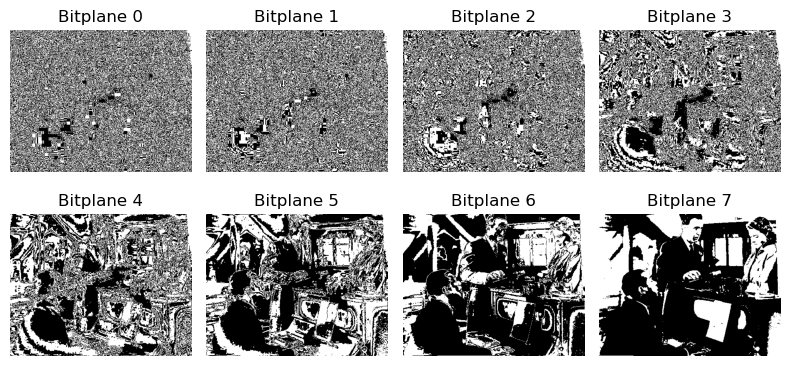

In [30]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i+1), plt.imshow(bitplanes[i], cmap='gray')
    plt.title(f'Bitplane {i}')
    plt.axis('off')
plt.tight_layout()

In [53]:
reconstructed_img = np.zeros([m, n])

In [54]:
for i in range(8):
    reconstructed_img = np.add(reconstructed_img, bitplanes[i])

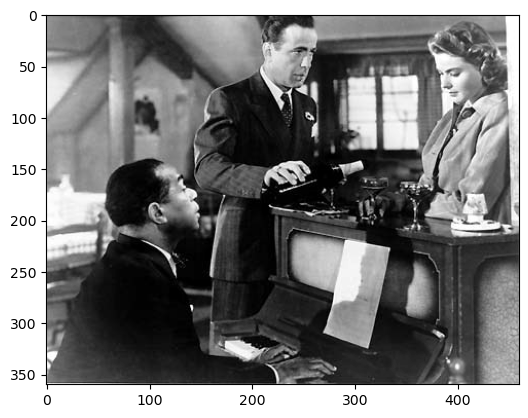

In [55]:
plt.imshow(reconstructed_img, cmap='gray')

In [63]:
# Unsharp masking

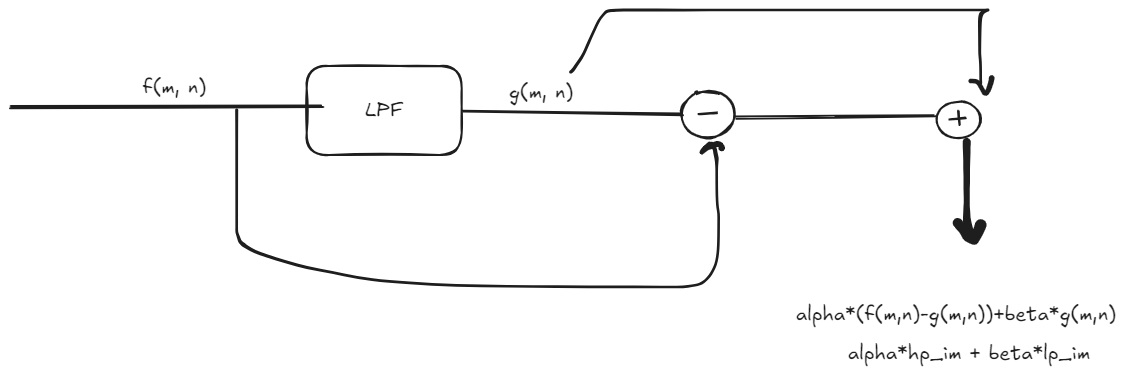

In [64]:
img = cv2.imread('Z:/20XW97-CV-LAB/assets/images/cameraman.tif', 0)

In [70]:
def unsharp_mask(img, alpha=0.5, beta=0.5):
    lpf = np.array([[1,1,1], [1, 1, 1], [1, 1, 1]])/9
    lp_im = cv2.filter2D(img, -1, lpf)
    
    hp_im = np.add(img, -lp_im)
    
    y = alpha*hp_im+beta*lp_im
    return y

In [84]:
unsharp_masked_img = unsharp_mask(img, 0.1, 0.9)

In [85]:
unsharp_masked_img.shape

(256, 256)

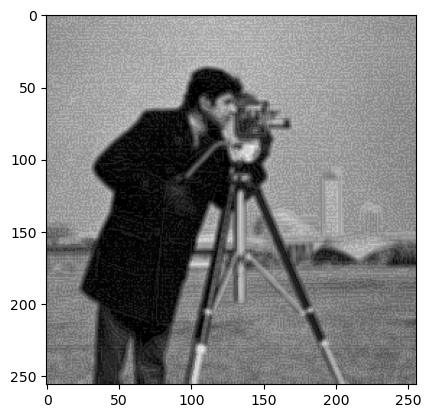

In [86]:
plt.imshow(unsharp_masked_img, cmap='gray')

In [116]:
# Logtransform
c = 255/np.log(1+255)

In [117]:
img = cv2.imread('Z:/20XW97-CV-LAB/assets/images/cameraman.tif', 0)
m, n = img.shape

In [118]:
res = np.zeros([256, 256])

for i in range(m):
    for j in range(n):
        res[i, j] = c*np.log(img[i, j]+1)

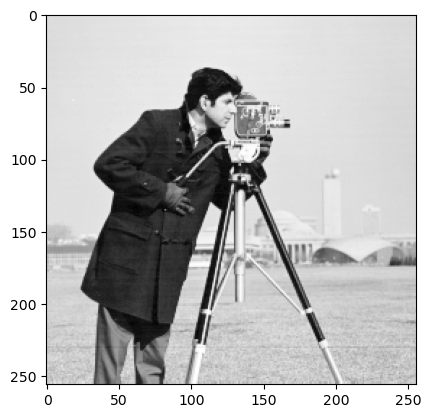

In [119]:
plt.imshow(res, cmap='gray')

In [124]:
# Gamma correction

In [125]:
img = cv2.imread('Z:/20XW97-CV-LAB/assets/images/cameraman.tif', 0)
m, n = img.shape

In [141]:
res = np.zeros([m, n])
c = 1
gamma = 2
for i in range(m):
    for j in range(n):
        res[i, j] = c*img[i, j]**gamma

(-0.5, 255.5, 255.5, -0.5)

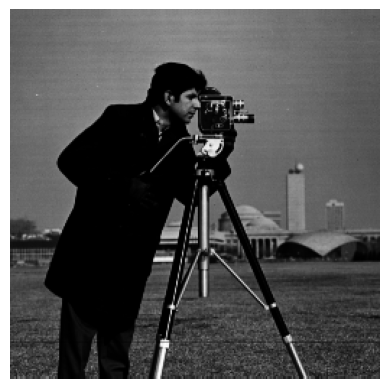

In [142]:
plt.imshow(res, cmap='gray')
plt.axis('off')

In [143]:
res

array([[24336., 25281., 24964., ..., 22801., 23104., 23104.],
       [25600., 23716., 24649., ..., 23716., 24025., 23409.],
       [24336., 25281., 24964., ..., 22801., 23104., 23104.],
       ...,
       [12996., 17424., 15129., ..., 18225., 18769., 12996.],
       [14641., 15876., 16900., ..., 17689., 16900., 12769.],
       [14641., 15876., 16900., ..., 17689., 16900., 12769.]])

In [135]:
# gray level slicing

In [138]:
T1 = 150
T2 = 200
res = np.zeros([m, n])

for i in range(m):
    for j in range(n):
        if T1<img[i, j]<T2:
            res[i, j] = 255
        else:
            res[i, j] = 0

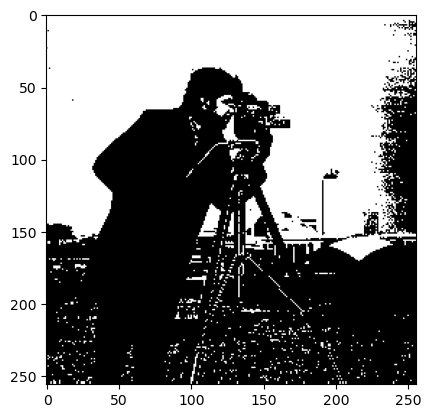

In [139]:
plt.imshow(res, cmap='gray')